# ***Credit Default Risk Prediction***

# **Problem Statement :**
Credit card defaults pose a significant financial risk to lending institutions. Early identification of high-risk customers allows banks to take preventive action before a default occurs. This project builds a supervised machine learning classification model trained on 30,000 real credit card customers to predict the probability of default in the following month. The model leverages six months of repayment behaviour, billing statements, payment amounts, and customer demographics — combining raw features with engineered signals such as utilization rate, payment ratio, and delay trends — to produce an interpretable risk score. The end deliverable is an interactive analyst tool where a loan officer can enter a customer's credit history and instantly receive a default probability with a clear approve, review, or reject recommendation."

# 1. Import Required Libraries

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel("default of credit card clients.xls", header=1)
df.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# 2. Understanding the Data

In [2]:
df.shape

(30000, 25)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [4]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [5]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

# 3. Data Cleaning

### Fix Wrong Categories

In [4]:
print("Education:", df["EDUCATION"].unique())
print("SEX:", df["SEX"].unique())
print("Marriage:", df["MARRIAGE"].unique())

Education: [2 1 3 5 4 6 0]
SEX: [2 1]
Marriage: [1 2 3 0]


In [5]:
# Map undocumented categories (0, 5, 6) to 'Other' (4) in EDUCATION
df["EDUCATION"] = df["EDUCATION"].replace([0, 5, 6], 4)
# Map undocumented 0 to 'Other' (3) in MARRIAGE
df["MARRIAGE"] = df["MARRIAGE"].replace(0, 3)

print("Education:", df["EDUCATION"].unique())
print("Marriage:", df["MARRIAGE"].unique())

Education: [2 1 3 4]
Marriage: [1 2 3]


### Drop Unnecessary Columns

In [6]:
df = df.drop(columns=["ID"])

### Check Missing Values

In [7]:
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

### Check & Drop Duplicates

In [8]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 35
Duplicates after: 0


### Target Analysis

In [9]:
print(df['default payment next month'].value_counts())
print("\nClass imbalance ratio:", round(df['default payment next month'].value_counts()[0] / df['default payment next month'].value_counts()[1], 2))

default payment next month
0    23335
1     6630
Name: count, dtype: int64

Class imbalance ratio: 3.52


# 4. EDA

# Target Distribution Chart 

<Axes: xlabel='default payment next month', ylabel='count'>

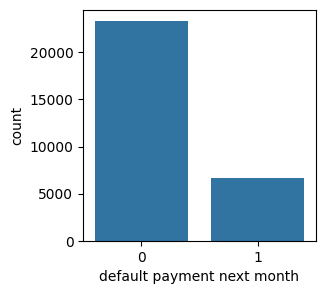

In [21]:
plt.figure(figsize=(3, 3))
sns.countplot(x='default payment next month', data=df)
# Shows 78% vs 22% split visually — this motivates why you used SMOTE and scale_pos_weight

# Default Rate by Key Categories 

<Axes: xlabel='EDUCATION'>

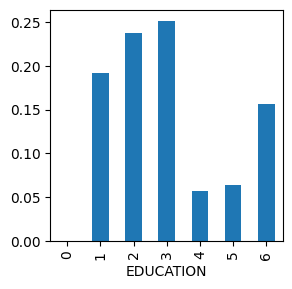

In [23]:
# Default rate by Education, Marriage, Sex
# e.g. "High school educated customers default more than graduates"
plt.figure(figsize=(3, 3))
df.groupby('EDUCATION')['default payment next month'].mean().plot(kind='bar')

# Credit Limit vs Default

<Axes: xlabel='default payment next month', ylabel='LIMIT_BAL'>

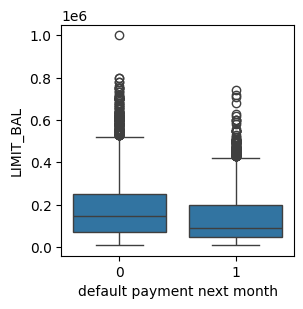

In [24]:
plt.figure(figsize=(3, 3))
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df)
# Shows defaulters tend to have lower credit limits — makes business sense

# Repayment Status Distribution

<Axes: xlabel='PAY_0', ylabel='count'>

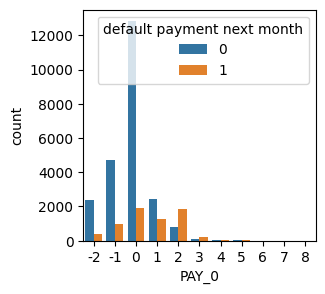

In [25]:
plt.figure(figsize=(3, 3))
sns.countplot(x='PAY_0', hue='default payment next month', data=df)
# Shows customers with delay status 2+ are heavily defaulting

# Age Distribution by Default

<Axes: xlabel='AGE', ylabel='Count'>

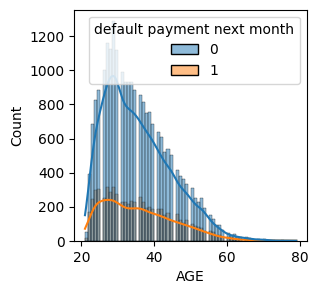

In [27]:
plt.figure(figsize=(3, 3))
sns.histplot(data=df, x='AGE', hue='default payment next month', kde=True)

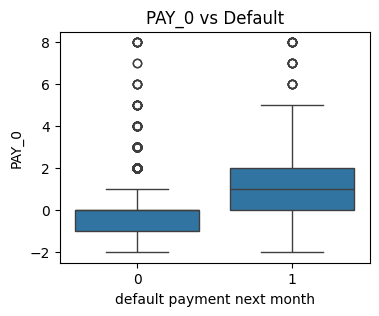

In [12]:
plt.figure(figsize=(4, 3))
sns.boxplot(x='default payment next month', y='PAY_0', data=df)
plt.title('PAY_0 vs Default')
plt.show()

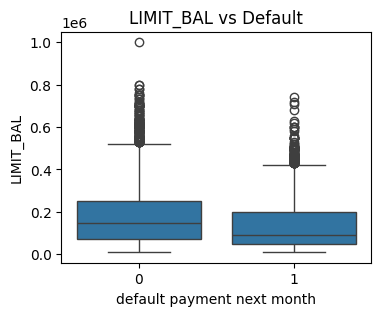

In [13]:
plt.figure(figsize=(4, 3))
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df)
plt.title('LIMIT_BAL vs Default')
plt.show()

# Heatmap

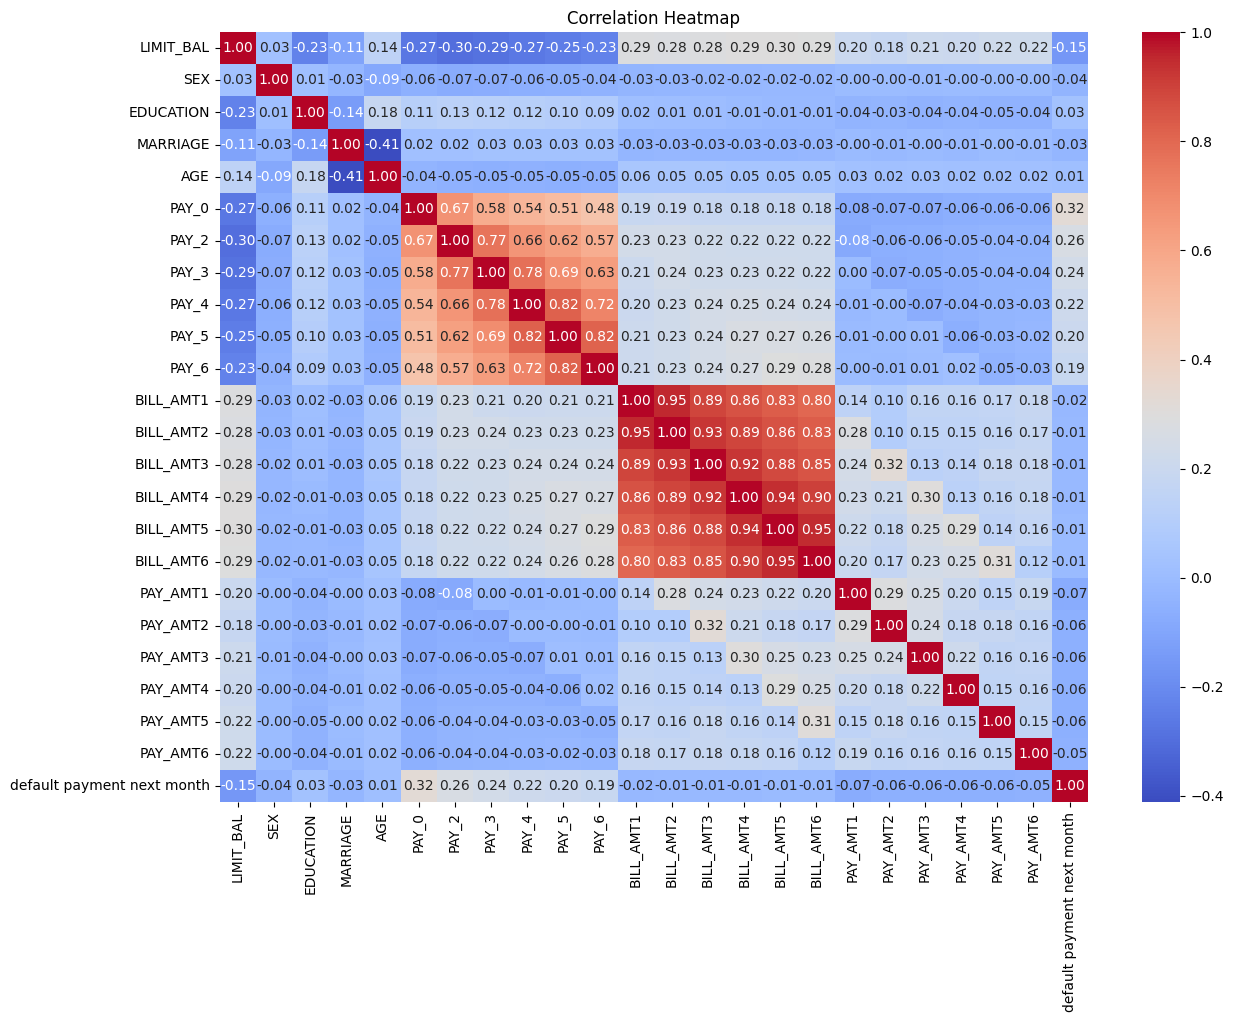

In [14]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 5. Feature Engineering

**Key Fix:** We do NOT drop BILL_AMT columns just because of high VIF.
VIF measures multicollinearity, NOT predictive power. Tree-based models (XGBoost, RF)
handle correlated features well. Instead, we keep them AND add meaningful derived features.

In [11]:
# --- Aggregated Bill Features (keep originals too) ---
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

# Total and average bill
df['total_bill']   = df[bill_cols].sum(axis=1)
df['avg_bill']     = df[bill_cols].mean(axis=1)

# Bill trend: is the bill growing month over month? (positive = growing debt)
df['bill_trend']   = df['BILL_AMT1'] - df['BILL_AMT6']

# Credit utilization ratio: how much of the limit is being used
df['util_rate']    = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)

# Total and average payment
df['total_pay']    = df[pay_amt_cols].sum(axis=1)
df['avg_pay']      = df[pay_amt_cols].mean(axis=1)

# Payment ratio: how much of the bill was paid last month
df['pay_ratio']    = df['PAY_AMT1'] / (df['BILL_AMT1'] + 1)

# Average payment delay across 6 months
pay_delay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
df['avg_pay_delay'] = df[pay_delay_cols].mean(axis=1)

# Max delay (worst repayment status)
df['max_pay_delay'] = df[pay_delay_cols].max(axis=1)

print("New features added. Shape:", df.shape)
df[['util_rate','pay_ratio','bill_trend','avg_pay_delay','max_pay_delay']].describe()

New features added. Shape: (29965, 33)


,util_rate,pay_ratio,bill_trend,avg_pay_delay,max_pay_delay
count,29965.000000,2.995700e+04,29965.000000,29965.000000,29965.000000
mean,0.424255,inf,12365.997497,-0.180978,0.439146
std,0.411442,NaN,43946.036412,0.981368,1.344934
min,-0.619890,-1.088325e+04,-428791.000000,-2.000000,-2.000000
25%,0.022298,3.444854e-02,-2976.000000,-0.833333,0.000000
50%,0.315277,5.570939e-02,933.000000,0.000000,0.000000
75%,0.830315,2.641782e-01,19827.000000,0.000000,2.000000
max,6.454977,inf,708323.000000,6.000000,8.000000


# 6. Select Features and Target

In [12]:
y = df['default payment next month']
X = df.drop(['default payment next month'], axis=1)

print("y shape:", y.shape)
print("X shape:", X.shape)
print("Features:", list(X.columns))

y shape: (29965,)
X shape: (29965, 32)
Features: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'total_bill', 'avg_bill', 'bill_trend', 'util_rate', 'total_pay', 'avg_pay', 'pay_ratio', 'avg_pay_delay', 'max_pay_delay']


# 7. Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("Train class distribution:\n", y_train.value_counts())

X_train: (23972, 32)
X_test:  (5993, 32)
Train class distribution:
 default payment next month
0    18668
1     5304
Name: count, dtype: int64


# 8. Outlier Handling (on Train only, then apply to Test)

In [14]:
# Only clip on columns that make sense — not binary/ordinal categoricals
clip_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1','BILL_AMT2','BILL_AMT3',
             'BILL_AMT4','BILL_AMT5','BILL_AMT6',
             'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
             'total_bill','avg_bill','bill_trend','total_pay','avg_pay',
             'util_rate','pay_ratio']

for col in clip_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Apply limits computed on train to BOTH train and test (no leakage)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

print("Outlier clipping done.")

Outlier clipping done.


# 9. Log-Transform Skewed Payment Columns

**Key Fix:** PAY_AMT columns are highly right-skewed (skew > 1.0).
Log-transform reduces skew and helps Logistic Regression, KNN, SVM significantly.

In [15]:
log_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
            'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
            'total_bill','avg_bill','total_pay','avg_pay','LIMIT_BAL']

for col in log_cols:
    # log1p handles zero values safely: log(1 + x)
    X_train[col] = np.log1p(X_train[col].clip(lower=0))
    X_test[col]  = np.log1p(X_test[col].clip(lower=0))

print("Skewness after log-transform:")
print(X_train[log_cols].skew().round(2))

Skewness after log-transform:
PAY_AMT1     -1.41
PAY_AMT2     -1.37
PAY_AMT3     -1.20
PAY_AMT4     -1.07
PAY_AMT5     -1.05
PAY_AMT6     -0.97
BILL_AMT1    -1.78
BILL_AMT2    -1.66
BILL_AMT3    -1.59
BILL_AMT4    -1.53
BILL_AMT5    -1.44
BILL_AMT6    -1.31
total_bill   -2.46
avg_bill     -2.03
total_pay    -2.90
avg_pay      -2.47
LIMIT_BAL    -0.52
dtype: float64


# 10. Preprocessing Pipeline (Scaling + Encoding)

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Categorical columns
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

# Numerical columns
num_cols = [c for c in X_train.columns if c not in cat_cols]

# Updated Preprocessor with Imputation
preprocessor = ColumnTransformer(transformers=[

    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  
        ('scaler', StandardScaler())
    ]), num_cols),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),  
        ('encoder', OneHotEncoder(drop='first', sparse_output=False))
    ]), cat_cols)

])

print("Numeric features:", len(num_cols))
print("Categorical features:", cat_cols)

Numeric features: 29
Categorical features: ['SEX', 'EDUCATION', 'MARRIAGE']


# 11. Model Training with GridSearchCV

**Key Fixes:**
- Use `roc_auc` as scoring (better for imbalanced data than raw F1)
- Use `scale_pos_weight` in XGBoost instead of SMOTE (more effective for boosting)
- SMOTE inside imblearn Pipeline so it's applied correctly per fold (no leakage)
- Removed deprecated `penalty` param from Logistic Regression

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Compute class weight ratio for XGBoost scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = round(neg / pos, 2)
print(f"XGBoost scale_pos_weight: {spw}  (neg={neg}, pos={pos})")

models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, class_weight='balanced'),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ['lbfgs']
        }
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(class_weight='balanced'),
        "params": {
            "model__max_depth": [5, 10, 15],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__criterion": ['gini', 'entropy']
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(class_weight='balanced', random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [10, 20, None],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1, 0.2],
            "model__max_depth": [3, 5],
            "model__subsample": [0.8, 1.0]
        }
    },

    # Using scale_pos_weight instead of SMOTE for XGBoost — works better
    "XGBoost": {
        "model": XGBClassifier(
            eval_metric='logloss',
            scale_pos_weight=spw,   # handles imbalance natively
            random_state=42
        ),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 5, 7],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
            "model__min_child_weight": [1, 3]
        }
    },
}

XGBoost scale_pos_weight: 3.52  (neg=18668, pos=5304)


In [26]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [27]:
results = []

for name, mp in models.items():
    print(f"Training: {name}...")

    # For XGBoost we skip SMOTE since scale_pos_weight handles imbalance
    if name == "XGBoost":
        pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('model', mp['model'])
        ])
    else:
        pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('smote', SMOTE(random_state=42)),  # applied inside CV fold — no leakage
            ('model', mp['model'])
        ])

    grid = GridSearchCV(
        pipeline,
        mp['params'],
        cv=cv,
        scoring='roc_auc',   #  roc_auc better for imbalanced classification
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    results.append({
        "Model": name,
        "CV ROC-AUC": round(grid.best_score_, 4),
        "Best Params": grid.best_params_,
        "Best Estimator": grid.best_estimator_
    })
    print(f"  -> Best CV ROC-AUC: {grid.best_score_:.4f}")

print("\nAll models trained!")

Training: Logistic Regression...
  -> Best CV ROC-AUC: 0.7623
Training: Decision Tree...
  -> Best CV ROC-AUC: 0.7608
Training: Random Forest...
  -> Best CV ROC-AUC: 0.7831
Training: Gradient Boosting...
  -> Best CV ROC-AUC: 0.7790
Training: XGBoost...
  -> Best CV ROC-AUC: 0.7892

All models trained!


# 12. CV Results Summary

In [28]:
results_df = pd.DataFrame([{"Model": r["Model"], "CV ROC-AUC": r["CV ROC-AUC"], "Best Params": r["Best Params"]} for r in results])
print(results_df.sort_values(by="CV ROC-AUC", ascending=False).to_string())

                 Model  CV ROC-AUC                                                                                                                                                               Best Params
4              XGBoost      0.7892  {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__subsample': 0.8}
2        Random Forest      0.7831                                                         {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
3    Gradient Boosting      0.7790                                                                {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
0  Logistic Regression      0.7623                                                                                                                              {'model__C': 0.01, '

# 13. Evaluate Best Model on Test Set

In [29]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)

# Pick best model by CV ROC-AUC
best_result = max(results, key=lambda x: x['CV ROC-AUC'])
best_model  = best_result['Best Estimator']
best_name   = best_result['Model']

print(f"Best Model: {best_name} (CV ROC-AUC: {best_result['CV ROC-AUC']})")

# Predict
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

# Metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")

Best Model: XGBoost (CV ROC-AUC: 0.7892)

--- Classification Report ---
              precision    recall  f1-score   support

  No Default       0.89      0.77      0.82      4667
     Default       0.44      0.65      0.53      1326

    accuracy                           0.74      5993
   macro avg       0.66      0.71      0.68      5993
weighted avg       0.79      0.74      0.76      5993

Test ROC-AUC: 0.7800


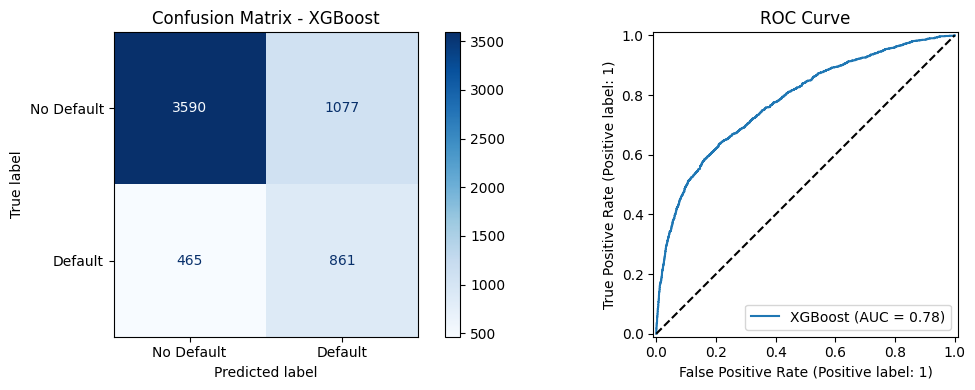

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Default', 'Default'],
    ax=axes[0], cmap='Blues'
)
axes[0].set_title(f'Confusion Matrix - {best_name}')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1], name=best_name)
axes[1].set_title('ROC Curve')
axes[1].plot([0,1],[0,1],'k--')

plt.tight_layout()
plt.show()

# 14. Evaluate All Models on Test Set

In [31]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

test_results = []
for r in results:
    model = r['Best Estimator']
    yp    = model.predict(X_test)
    ypp   = model.predict_proba(X_test)[:, 1]
    test_results.append({
        "Model":      r['Model'],
        "ROC-AUC":    round(roc_auc_score(y_test, ypp), 4),
        "F1 (Default)": round(f1_score(y_test, yp), 4),
        "Precision":  round(precision_score(y_test, yp), 4),
        "Recall":     round(recall_score(y_test, yp), 4),
        "Accuracy":   round(accuracy_score(y_test, yp), 4)
    })

test_df = pd.DataFrame(test_results).sort_values(by='ROC-AUC', ascending=False)
print(test_df.to_string(index=False))

              Model  ROC-AUC  F1 (Default)  Precision  Recall  Accuracy
            XGBoost   0.7800        0.5276     0.4443  0.6493    0.7427
      Random Forest   0.7709        0.5305     0.5055  0.5581    0.7814
  Gradient Boosting   0.7700        0.5142     0.5645  0.4721    0.8026
Logistic Regression   0.7547        0.5174     0.4447  0.6184    0.7447
      Decision Tree   0.7511        0.5072     0.4741  0.5452    0.7656


# 15. Feature Importance (XGBoost)

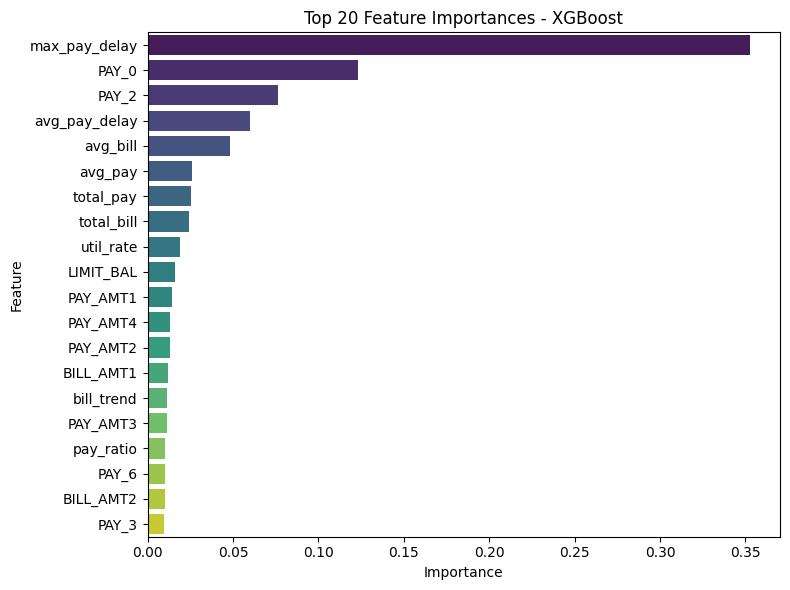

In [32]:
# Get feature names after preprocessing
xgb_result = next((r for r in results if r['Model'] == 'XGBoost'), None)

if xgb_result:
    xgb_pipeline = xgb_result['Best Estimator']
    
    # Get feature names from ColumnTransformer
    ohe_features  = list(xgb_pipeline.named_steps['preprocessing']
                         .named_transformers_['cat']
                         .get_feature_names_out(cat_cols))
    feature_names = num_cols + ohe_features
    
    importances = xgb_pipeline.named_steps['model'].feature_importances_
    imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    imp_df = imp_df.sort_values('Importance', ascending=False).head(20)
    
    plt.figure(figsize=(8, 6))
    sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
    plt.title('Top 20 Feature Importances - XGBoost')
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost not found in results.")

In [33]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))

# Summary of Fixes Applied

| Issue in Original | Fix Applied |
|---|---|
| BILL_AMT1-6 dropped based on VIF | **Kept all BILL columns** — VIF ≠ feature importance |
| No derived features | Added `util_rate`, `pay_ratio`, `bill_trend`, `avg_pay_delay`, `max_pay_delay` |
| PAY_AMT skew not handled | **Log-transform (log1p)** applied to skewed columns |
| Scoring: raw `f1` | Changed to **`roc_auc`** — better for imbalanced classification |
| SMOTE for XGBoost | Used **`scale_pos_weight`** instead — native, more effective |
| `stratify=None` in split | Added **`stratify=y`** to preserve class ratio in splits |
| Deprecated `penalty='l2'` warning | Removed deprecated param from LogisticRegression |
| No test-set evaluation | Added full **test evaluation** with F1, ROC-AUC, confusion matrix |
| No feature importance | Added **XGBoost feature importance** plot |